In [1]:
from qiskit import __version__
print(__version__)

2.1.1


In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, Pauli, DensityMatrix, partial_trace
from qiskit_aer import AerSimulator
from qiskit_aer.library import SaveDensityMatrix
from qiskit.visualization import plot_histogram
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.circuit.library import HGate, UnitaryGate, CXGate, RYGate, XGate, ZGate
import matplotlib.pyplot as plt
from line_profiler import LineProfiler

In [3]:
theta = np.arctan(np.sqrt((np.sqrt(5) - 1) / 2))
amp_0 = np.cos(theta/2)
amp_1 = np.sin(theta/2)

In [4]:
H_matrix = HGate().to_matrix()
hadamard_custom = UnitaryGate(H_matrix, label='hadamard_custom')

CX_matrix = CXGate().to_matrix()
cx_custom = UnitaryGate(CX_matrix, label='cx_custom')

RY_matrix = RYGate(theta).to_matrix()
ry_custom = UnitaryGate(RY_matrix, label='ry_custom')

X_matrix = XGate().to_matrix()
x_custom = UnitaryGate(X_matrix, label='x_custom')

Z_matrix = ZGate().to_matrix()
z_custom = UnitaryGate(Z_matrix, label='z_custom')

# Infidelity to error rates

In [5]:
def inf_to_error(infidelity_list, num_qubits):
    error_rates_list = []
    dimension = 2**num_qubits
    for infidelity in infidelity_list:
        error_rates_list.append( infidelity * (dimension / (dimension - 1)) )
    
    return error_rates_list

In [6]:
one_qubit_gate_infidelity = [2.8e-5 * i for i in range(1,6)]
two_qubit_gate_infidelity = [8.3e-4 * i for i in range(1,6)]
idle_gate_infidelity = [1.2e-4 * i for i in range(1,6)]
spam0 = [6.7e-4 * i for i in range(1,6)] # P(1|0), measured 1 given that 0 was prepared
spam1 = [1.2e-3 * i for i in range(1,6)] # P(0|1)

In [7]:
one_qubit_gate_error_prob = inf_to_error(one_qubit_gate_infidelity, num_qubits=1)
two_qubit_gate_error_prob = inf_to_error(two_qubit_gate_infidelity, num_qubits=2)
idle_gate_error_prob = inf_to_error(idle_gate_infidelity, num_qubits=1)

# Functions

Qubits are ordered from top to down, left to right, increasingly

The logical operators act on the left side of the triangle

In [8]:
def ideal_encoding(qc: QuantumCircuit, start: int):
    for i in [2,3,5]:
        qc.append(hadamard_custom, [start+i])
        
    cx_list = [[0,4], [0,1], [2,6], [2,4], [2,0], [5,6], [5,1], [5,0], [3,6], [3,1], [3,4]]
    for cx in cx_list:
        cx[0] += start
        cx[1] += start
        qc.append(cx_custom, cx)

In [9]:
def encoding(qc: QuantumCircuit, start: int):
    for i in [2,3,5]:
        qc.h(start+i)
    
    cx_list = [[0,4], [0,1], [2,6], [2,4], [2,0], [5,6], [5,1], [5,0], [3,6], [3,1], [3,4]]
    for cx in cx_list:
        cx[0] += start 
        cx[1] += start 
        qc.cx(cx[0], cx[1])

In [10]:
def ideal_syndrome_meas(qc, start, ancillas_start, x_syndrome, z_syndrome):
    for i in range(3):
        qc.append(hadamard_custom, [ancillas_start + i])
    
    for i in [0,1,2,3]:
        qc.append(cx_custom, [ancillas_start, start+i])
    for i in [1,2,4,5]:
        qc.append(cx_custom, [ancillas_start+1, start+i])
    for i in [2,3,5,6]:
        qc.append(cx_custom, [ancillas_start+2, start+i])
        
    for i in range(3):
        qc.append(hadamard_custom, [ancillas_start + i])
    
    qc.measure([ancillas_start+i for i in range(3)], x_syndrome)
    qc.reset([ancillas_start+i for i in range(3)])
    
    for i in [0,1,2,3]:
        qc.append(cx_custom, [start+i, ancillas_start])
    for i in [1,2,4,5]:
        qc.append(cx_custom, [start+i, ancillas_start+1])
    for i in [2,3,5,6]:
        qc.append(cx_custom, [start+i, ancillas_start+2])
        
    qc.measure([ancillas_start+i for i in range(3)], z_syndrome)
    qc.reset([ancillas_start+i for i in range(3)])

In [11]:
def ideal_logical_rz(qc: QuantumCircuit, start: int):
    qc.append(cx_custom, [start+6, start+5])
    qc.append(rzz_custom, [start+4, start+5])
    qc.append(cx_custom, [start+6, start+5])

In [12]:
def logical_rz(qc: QuantumCircuit, start: int, theta: float):
    qc.cx(start+6, start+5)
    qc.rzz(theta, start+4, start+5)
    qc.cx(start+6, start+5)

In [13]:
def ideal_recovery(qc: QuantumCircuit, start: int, x_syndrome: ClassicalRegister, z_syndrome: ClassicalRegister):
    with qc.if_test((x_syndrome, 0b001)):
        qc.append(z_custom, [start])
    with qc.if_test((x_syndrome, 0b010)):
        qc.append(z_custom, [start+4])
    with qc.if_test((x_syndrome, 0b011)):
        qc.append(z_custom, [start+1])
    with qc.if_test((x_syndrome, 0b100)):
        qc.append(z_custom, [start+6])
    with qc.if_test((x_syndrome, 0b101)):
        qc.append(z_custom, [start+3])
    with qc.if_test((x_syndrome, 0b110)):
        qc.append(z_custom, [start+5])
    with qc.if_test((x_syndrome, 0b111)):
        qc.append(z_custom, [start+2])
        

    with qc.if_test((z_syndrome, 0b001)):
        qc.append(x_custom, [start])
    with qc.if_test((z_syndrome, 0b010)):
        qc.append(x_custom, [start+4])
    with qc.if_test((z_syndrome, 0b011)):
        qc.append(x_custom, [start+1])
    with qc.if_test((z_syndrome, 0b100)):
        qc.append(x_custom, [start+6])
    with qc.if_test((z_syndrome, 0b101)):
        qc.append(x_custom, [start+3])
    with qc.if_test((z_syndrome, 0b110)):
        qc.append(x_custom, [start+5])
    with qc.if_test((z_syndrome, 0b111)):
        qc.append(x_custom, [start+2])

# Testing syndrome measurements

In [14]:
test = QuantumCircuit(7)

x_ancillas = QuantumRegister(3)
z_ancillas = QuantumRegister(3)
x_syndrome = ClassicalRegister(3)
z_syndrome = ClassicalRegister(3)

test.add_register(x_ancillas, z_ancillas, x_syndrome, z_syndrome)

#test.x(5)
ideal_encoding(test, 0)
ideal_syndrome_meas(test, 0, x_ancillas, z_ancillas, x_syndrome, z_syndrome)

noise_model = NoiseModel()
meas_circuit_noise = test.copy()
meas_circuit_noise.save_statevector(label='state_post', pershot=True, conditional=True)

backend = AerSimulator(noise_model=noise_model)
job = backend.run(meas_circuit_noise, shots=1)
result = job.result()
res_statevectors = result.data()['state_post']
print(res_statevectors)

TypeError: ideal_syndrome_meas() takes 5 positional arguments but 6 were given

In [ ]:
test1 = QuantumCircuit(21,14)
ideal_encoding(test1, 0)
ideal_encoding(test1, 7)
ideal_encoding(test1, 14)

for i in range(21):
    test1.s(i)
    test1.h(i)
ideal_logical_rz(test1, 0, theta)
ideal_logical_rz(test1, 7, theta)
ideal_logical_rz(test1, 14, theta)
for i in range(21):
    test1.h(i)
    test1.sdg(i)
    
x_ancillas1 = QuantumRegister(3)
z_ancillas1 = QuantumRegister(3)
x_syndrome1 = ClassicalRegister(3)
z_syndrome1 = ClassicalRegister(3)

test1.add_register(x_ancillas1, z_ancillas1, x_syndrome1, z_syndrome1)
    
ideal_syndrome_meas(test1, 14, x_ancillas1, z_ancillas1, x_syndrome1, z_syndrome1)

TypeError: ideal_logical_rz() takes 2 positional arguments but 3 were given

In [ ]:
noise_model = NoiseModel()
meas_circuit_noise = test1.copy()

backend = AerSimulator(noise_model=noise_model)
transpiled = transpile(meas_circuit_noise, backend, optimization_level=0)
job = backend.run(transpiled, shots=1)
result = job.result()
counts = result.get_counts()
print(counts)

{'000 000 00000000000000': 1}


# Finding probability of success

In [ ]:
circuit = QuantumCircuit(21,14)
for i in [0,7,14]:
    circuit.append(ry_custom, [i])
ideal_encoding(circuit, 0)
ideal_encoding(circuit, 7)
ideal_encoding(circuit, 14)
 
for i in range(7):
    circuit.cz(i, i+7)
    circuit.h(i+14)

for i in range(7):
    circuit.cz(i+7, i+14)
    
for i in range(14):
    circuit.h(i)

In [ ]:
shots = 1_000

noise_model = NoiseModel()
meas_circuit_noise = circuit.copy()
meas_circuit_noise.measure([i for i in range(14)], [i for i in range(14)]) 

backend = AerSimulator(noise_model=noise_model)
job = backend.run(meas_circuit_noise, shots=shots)
result = job.result()

counts = result.get_counts()

correct = 0
for key, values in counts.items():
    block1_syndrome = str(key)[0:7]
    block2_syndrome = str(key)[7:14]
    
    block1_parity1 = (int(block1_syndrome[-1]) + int(block1_syndrome[-2]) + int(block1_syndrome[-3]) + int(block1_syndrome[-4])) % 2
    block1_parity2 = (int(block1_syndrome[-2]) + int(block1_syndrome[-3]) + int(block1_syndrome[-5]) + int(block1_syndrome[-6])) % 2
    block1_parity3 = (int(block1_syndrome[-3]) + int(block1_syndrome[-4]) + int(block1_syndrome[-6]) + int(block1_syndrome[-7])) % 2
    block1_logical_op = (int(block1_syndrome[-1]) + int(block1_syndrome[-2]) + int(block1_syndrome[-5])) % 2 
    
    block2_parity1 = (int(block2_syndrome[-1]) + int(block2_syndrome[-2]) + int(block2_syndrome[-3]) + int(block2_syndrome[-4])) % 2
    block2_parity2 = (int(block2_syndrome[-2]) + int(block2_syndrome[-3]) + int(block2_syndrome[-5]) + int(block2_syndrome[-6])) % 2
    block2_parity3 = (int(block2_syndrome[-3]) + int(block2_syndrome[-4]) + int(block2_syndrome[-6]) + int(block2_syndrome[-7])) % 2
    block2_logical_op = (int(block2_syndrome[-1]) + int(block2_syndrome[-2]) + int(block2_syndrome[-5])) % 2
    
    parity_list = [block1_parity1, block1_parity2, block1_parity3, block1_logical_op, block2_parity1, block2_parity2, block2_parity3, block2_logical_op]
    if (parity_list == [0,0,0,0,0,0,0,0]):
        correct += values

print(f"Probability of measuring correct outputs: {correct/shots * 100}%")

Probability of measuring correct outputs: 41.4%


# Fidelity Simulations

In [15]:
ideal = QuantumCircuit(7)
ideal.append(ry_custom, [0])
ideal_encoding(ideal, 0)
    
ideal = Statevector(ideal)

In [16]:
circuit = QuantumCircuit(21,14)
for i in [0,7,14]:
    circuit.ry(theta, i)
encoding(circuit, 0)
encoding(circuit, 7)
encoding(circuit, 14)
    
for i in range(7):
    circuit.cz(i, i+7)
    circuit.h(i+14)

for i in range(7):
    circuit.cz(i+7, i+14)
    
for i in range(14):
    circuit.h(i)

In [ ]:
# All errors added
all_fidelity = []
all_fidelity_unc = []
shot_count = 100
#trace_list = [i for i in range(14)] + [i for i in range(21, 24)]
trace_list = [i for i in range(14)]

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['h'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_gate_error_prob[i], 2), ['cz'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_gate_error_prob[i], 2), ['cx']) 
    
    readout_err = ReadoutError([[1-spam0[i], spam0[i]],  # P(0|0), P(1|0)
                            [spam1[i], 1-spam1[i]]]) # P(0|1), P(1|1)
    noise_model.add_readout_error(readout_err, [0])
    noise_model.add_readout_error(readout_err, [1])
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([i for i in range(14)], [i for i in range(14)]) 
    meas_circuit_noise.reset([0,1,2])
    
    x_syndrome = ClassicalRegister(3)
    z_syndrome = ClassicalRegister(3)
    meas_circuit_noise.add_register(x_syndrome, z_syndrome)
    ideal_syndrome_meas(meas_circuit_noise, 14, 0, x_syndrome, z_syndrome)
    ideal_recovery(meas_circuit_noise, 14, x_syndrome, z_syndrome)
    
    meas_circuit_noise.save_statevector(label='state_post', pershot=True, conditional=True)

    backend = AerSimulator(noise_model=noise_model, method='statevector')
    job = backend.run(meas_circuit_noise, shots=shot_count)
    result = job.result()
    
    res_statevectors = result.data()['state_post']
    sumfid = 0
    correct = 0
    for key, sv_list in res_statevectors.items():
        binary_string = format(int(key, 16), 'b').zfill(14)
        
        block1_syndrome = str(binary_string)[0:7]
        block2_syndrome = str(binary_string)[7:14]
        
        block1_parity1 = (int(block1_syndrome[-1]) + int(block1_syndrome[-2]) + int(block1_syndrome[-3]) + int(block1_syndrome[-4])) % 2
        block1_parity2 = (int(block1_syndrome[-2]) + int(block1_syndrome[-3]) + int(block1_syndrome[-5]) + int(block1_syndrome[-6])) % 2
        block1_parity3 = (int(block1_syndrome[-3]) + int(block1_syndrome[-4]) + int(block1_syndrome[-6]) + int(block1_syndrome[-7])) % 2
        block1_logical_op = (int(block1_syndrome[-1]) + int(block1_syndrome[-2]) + int(block1_syndrome[-5])) % 2 
        
        block2_parity1 = (int(block2_syndrome[-1]) + int(block2_syndrome[-2]) + int(block2_syndrome[-3]) + int(block2_syndrome[-4])) % 2
        block2_parity2 = (int(block2_syndrome[-2]) + int(block2_syndrome[-3]) + int(block2_syndrome[-5]) + int(block2_syndrome[-6])) % 2
        block2_parity3 = (int(block2_syndrome[-3]) + int(block2_syndrome[-4]) + int(block2_syndrome[-6]) + int(block2_syndrome[-7])) % 2
        block2_logical_op = (int(block2_syndrome[-1]) + int(block2_syndrome[-2]) + int(block2_syndrome[-5])) % 2
        
        parity_list = [block1_parity1, block1_parity2, block1_parity3, block1_logical_op, block2_parity1, block2_parity2, block2_parity3, block2_logical_op]
        if (parity_list == [0,0,0,0,0,0,0,0]):
            correct += len(sv_list)
            for sv in sv_list:
                red_sv = partial_trace(sv, trace_list)
                sumfid += state_fidelity(ideal, red_sv)
    sumfid /= correct
    
    all_fidelity.append(sumfid)
    all_fidelity_unc.append( 1.96 * np.sqrt( (sumfid)*(1 - sumfid) / correct) )

all_infidelity = [1-f for f in all_fidelity]

In [17]:
# Input infidelities
ry_theta = np.array([[np.cos(theta/2), -np.sin(theta/2)], [np.sin(theta/2), np.cos(theta/2)]])

one_q_zero_dm = np.matmul([[1], [0]], [[1,0]])
ideal_input = ry_theta @ one_q_zero_dm @ ry_theta.conj().T

ideal_input /= np.trace(ideal_input)
ideal_input = DensityMatrix(ideal_input)

input_circuit = QuantumCircuit(1)
input_circuit.ry(theta, 0) 

In [18]:
all_fidelity_input = []
shots = 1

for i in range(len(one_qubit_gate_error_prob)):
    nm = NoiseModel()
    
    nm.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ["ry"])
    
    input_copy = input_circuit.copy()
    #input_copy.save_density_matrix(label='density_matrix_post', pershot=True, conditional=True)
    input_copy.append(SaveDensityMatrix(num_qubits=1, label='density_matrix_post', conditional=True, pershot=True), input_copy.qubits)
    
    backend = AerSimulator(noise_model=nm, method='density_matrix')
    job = backend.run(input_copy, shots=shots)
    result = job.result()

    res_density_matrix = result.data()['density_matrix_post']
    
    all_fidelity_input.append(state_fidelity(ideal_input, res_density_matrix[''][0]))

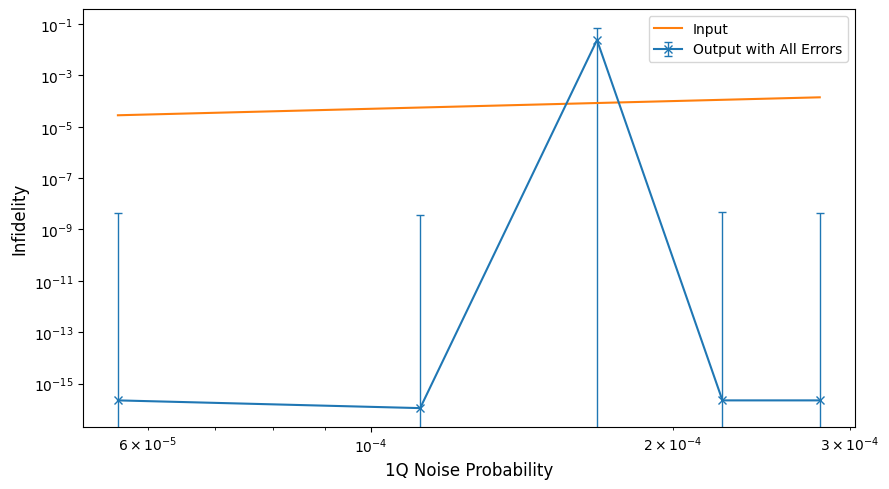

In [ ]:
plt.figure(figsize=(9, 5))
plt.errorbar(
    one_qubit_gate_error_prob,
    all_infidelity,
    yerr=all_fidelity_unc,
    fmt=f'x-',
    capsize=3,
    elinewidth=1,
    label='Output with All Errors'
)
plt.plot(one_qubit_gate_error_prob, [1-f for f in all_fidelity_input], label='Input')

plt.xlabel("1Q Noise Probability", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.legend()
plt.show()

Running more shots

In [19]:
def all_errors(sum_fid_array, correct_array, total_shots, shot_count=2_000):
    trace_list = [i for i in range(14)]
    for i in range(len(one_qubit_gate_error_prob)):
        noise_model = NoiseModel()
        
        noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['h'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_gate_error_prob[i], 2), ['cz'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_gate_error_prob[i], 2), ['cx']) 
        
        readout_err = ReadoutError([[1-spam0[i], spam0[i]],  # P(0|0), P(1|0)
                                [spam1[i], 1-spam1[i]]]) # P(0|1), P(1|1)
        noise_model.add_readout_error(readout_err, [0])
        noise_model.add_readout_error(readout_err, [1])
        
        meas_circuit_noise = circuit.copy()
        meas_circuit_noise.measure([i for i in range(14)], [i for i in range(14)]) 
        meas_circuit_noise.reset([0,1,2])
        
        x_syndrome = ClassicalRegister(3)
        z_syndrome = ClassicalRegister(3)
        meas_circuit_noise.add_register(x_syndrome, z_syndrome)
        ideal_syndrome_meas(meas_circuit_noise, 14, 0, x_syndrome, z_syndrome)
        ideal_recovery(meas_circuit_noise, 14, x_syndrome, z_syndrome) 
        meas_circuit_noise.save_statevector(label='state_post', pershot=True, conditional=True)

        backend = AerSimulator(noise_model=noise_model, method='statevector')
        job = backend.run(meas_circuit_noise, shots=shot_count)
        result = job.result()
        
        res_statevectors = result.data()['state_post']
        sumfid = 0
        correct = 0
        for key, sv_list in res_statevectors.items():
            binary_string = format(int(key, 16), 'b').zfill(14)
            
            block1_syndrome = str(binary_string)[0:7]
            block2_syndrome = str(binary_string)[7:14]
            
            block1_parity1 = (int(block1_syndrome[-1]) + int(block1_syndrome[-2]) + int(block1_syndrome[-3]) + int(block1_syndrome[-4])) % 2
            block1_parity2 = (int(block1_syndrome[-2]) + int(block1_syndrome[-3]) + int(block1_syndrome[-5]) + int(block1_syndrome[-6])) % 2
            block1_parity3 = (int(block1_syndrome[-3]) + int(block1_syndrome[-4]) + int(block1_syndrome[-6]) + int(block1_syndrome[-7])) % 2
            block1_logical_op = (int(block1_syndrome[-1]) + int(block1_syndrome[-2]) + int(block1_syndrome[-5])) % 2 
            
            block2_parity1 = (int(block2_syndrome[-1]) + int(block2_syndrome[-2]) + int(block2_syndrome[-3]) + int(block2_syndrome[-4])) % 2
            block2_parity2 = (int(block2_syndrome[-2]) + int(block2_syndrome[-3]) + int(block2_syndrome[-5]) + int(block2_syndrome[-6])) % 2
            block2_parity3 = (int(block2_syndrome[-3]) + int(block2_syndrome[-4]) + int(block2_syndrome[-6]) + int(block2_syndrome[-7])) % 2
            block2_logical_op = (int(block2_syndrome[-1]) + int(block2_syndrome[-2]) + int(block2_syndrome[-5])) % 2
            
            parity_list = [block1_parity1, block1_parity2, block1_parity3, block1_logical_op, block2_parity1, block2_parity2, block2_parity3, block2_logical_op]
            if (parity_list == [0,0,0,0,0,0,0,0]):
                correct += len(sv_list)
                for sv in sv_list:
                    red_sv = partial_trace(sv, trace_list)
                    sumfid += state_fidelity(ideal, red_sv)
        
        sum_fid_array[i] += sumfid
        correct_array[i] += correct
    total_shots += shot_count
        
    return sum_fid_array, correct_array, total_shots

In [20]:
def no_errors(sum_fid_array, correct_array, total_shots, shot_count=2_000):
    trace_list = [i for i in range(14)]
    for i in range(len(one_qubit_gate_error_prob)):
        noise_model = NoiseModel()
        
        noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
        
        meas_circuit_noise = circuit.copy()
        meas_circuit_noise.measure([i for i in range(14)], [i for i in range(14)]) 
        meas_circuit_noise.reset([0,1,2])
        
        x_syndrome = ClassicalRegister(3)
        z_syndrome = ClassicalRegister(3)
        meas_circuit_noise.add_register(x_syndrome, z_syndrome)
        ideal_syndrome_meas(meas_circuit_noise, 14, 0, x_syndrome, z_syndrome)
        ideal_recovery(meas_circuit_noise, 14, x_syndrome, z_syndrome)
        meas_circuit_noise.save_statevector(label='state_post', pershot=True, conditional=True)

        backend = AerSimulator(noise_model=noise_model, method='statevector')
        job = backend.run(meas_circuit_noise, shots=shot_count)
        result = job.result()
        
        res_statevectors = result.data()['state_post']
        sumfid = 0
        correct = 0
        for key, sv_list in res_statevectors.items():
            binary_string = format(int(key, 16), 'b').zfill(14)
            
            block1_syndrome = str(binary_string)[0:7]
            block2_syndrome = str(binary_string)[7:14]
            
            block1_parity1 = (int(block1_syndrome[-1]) + int(block1_syndrome[-2]) + int(block1_syndrome[-3]) + int(block1_syndrome[-4])) % 2
            block1_parity2 = (int(block1_syndrome[-2]) + int(block1_syndrome[-3]) + int(block1_syndrome[-5]) + int(block1_syndrome[-6])) % 2
            block1_parity3 = (int(block1_syndrome[-3]) + int(block1_syndrome[-4]) + int(block1_syndrome[-6]) + int(block1_syndrome[-7])) % 2
            block1_logical_op = (int(block1_syndrome[-1]) + int(block1_syndrome[-2]) + int(block1_syndrome[-5])) % 2 
            
            block2_parity1 = (int(block2_syndrome[-1]) + int(block2_syndrome[-2]) + int(block2_syndrome[-3]) + int(block2_syndrome[-4])) % 2
            block2_parity2 = (int(block2_syndrome[-2]) + int(block2_syndrome[-3]) + int(block2_syndrome[-5]) + int(block2_syndrome[-6])) % 2
            block2_parity3 = (int(block2_syndrome[-3]) + int(block2_syndrome[-4]) + int(block2_syndrome[-6]) + int(block2_syndrome[-7])) % 2
            block2_logical_op = (int(block2_syndrome[-1]) + int(block2_syndrome[-2]) + int(block2_syndrome[-5])) % 2
            
            parity_list = [block1_parity1, block1_parity2, block1_parity3, block1_logical_op, block2_parity1, block2_parity2, block2_parity3, block2_logical_op]
            if (parity_list == [0,0,0,0,0,0,0,0]):
                correct += len(sv_list)
                for sv in sv_list:
                    red_sv = partial_trace(sv, trace_list)
                    sumfid += state_fidelity(ideal, red_sv)

        sum_fid_array[i] += sumfid
        correct_array[i] += correct
    total_shots += shot_count
        
    return sum_fid_array, correct_array, total_shots

In [21]:
sum_fid1 = np.zeros(len(one_qubit_gate_error_prob), dtype=float)
correct1 = np.zeros(len(one_qubit_gate_error_prob), dtype=int)
total_shots1 = 0

sum_fid2 = np.zeros(len(one_qubit_gate_error_prob), dtype=float)
correct2 = np.zeros(len(one_qubit_gate_error_prob), dtype=int)
total_shots2 = 0

In [19]:
sum_fid1, correct1, total_shots1 = all_errors(sum_fid1, correct1, total_shots1)
print(total_shots1)

6000


In [20]:
np.savez("results1.npz",
    sum_fid1=sum_fid1,
    correct1=correct1,
    total_shots1=total_shots1
)

In [28]:
data = np.load("results1.npz")
sum_fid1     = data["sum_fid1"]
correct1     = data["correct1"]
total_shots1 = int(data["total_shots1"])

In [32]:
sum_fid2, correct2, total_shots2 = no_errors(sum_fid2, correct2, total_shots2)
print(total_shots2)

26000


In [33]:
sum_fid2, correct2, total_shots2 = no_errors(sum_fid2, correct2, total_shots2)
print(total_shots2)

28000


In [34]:
sum_fid2, correct2, total_shots2 = no_errors(sum_fid2, correct2, total_shots2)
print(total_shots2)

30000


In [35]:
np.savez("results2.npz",
    sum_fid2=sum_fid2,
    correct2=correct2,
    total_shots2=total_shots2
)

In [22]:
data = np.load("results2.npz")
sum_fid2     = data["sum_fid2"]
correct2     = data["correct2"]
total_shots2 = int(data["total_shots2"])

In [37]:
all_fidelity = []
all_fidelity_unc = []
all_fidelity_ideal = []
all_fidelity_unc_ideal = []
for i in range(len(one_qubit_gate_error_prob)):
    temp1 = sum_fid1[i] / correct1[i]
    all_fidelity.append(temp1)
    all_fidelity_unc.append( 1.96 * np.sqrt( (temp1)*(1 - temp1) / correct1[i]) )
    
    temp2 = sum_fid2[i] / correct2[i]
    all_fidelity_ideal.append(temp2)
    all_fidelity_unc_ideal.append( 1.96 * np.sqrt( (temp2)*(1 - temp2) / correct2[i]) )

In [38]:
print(len(all_fidelity))
print(len(all_fidelity_ideal))
print(len(all_fidelity_input))

5
5
5


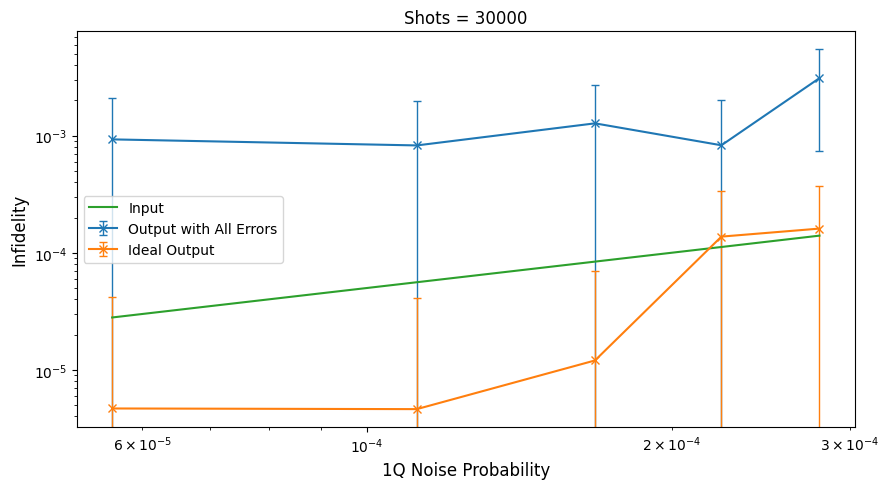

In [40]:
plt.figure(figsize=(9, 5))
plt.errorbar(
    one_qubit_gate_error_prob,
    [1-f for f in all_fidelity],
    yerr=all_fidelity_unc,
    fmt=f'x-',
    capsize=3,
    elinewidth=1,
    label='Output with All Errors'
)
plt.errorbar(
    one_qubit_gate_error_prob,
    [1-f for f in all_fidelity_ideal],
    yerr=all_fidelity_unc_ideal,
    fmt=f'x-',
    capsize=3,
    elinewidth=1,
    label='Ideal Output'
)
plt.plot(one_qubit_gate_error_prob, [1-f for f in all_fidelity_input], label='Input')

plt.xlabel("1Q Noise Probability", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.title(f"Shots = {total_shots2}")
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.legend()
plt.show()